# Notebook 02 — Exploratory Analysis & Visualisation
**Authors:** Adeesha & Thaweesha  
**Role:** Documentation & Visualisation  
**Task:** Load cleaned data from HDFS → Analyse → Create report-quality charts → Save outputs

---
> **Prerequisite:** `01_data_cleaning.ipynb` must have been run first.

## 1. Load Packages

In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

os.makedirs("output/visualisations", exist_ok=True)

# Consistent chart styling across all charts
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"]        = 130
plt.rcParams["font.family"]        = "DejaVu Sans"
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False
plt.rcParams["axes.titlesize"]     = 13
plt.rcParams["axes.labelsize"]     = 11
plt.rcParams["xtick.labelsize"]    = 10
plt.rcParams["ytick.labelsize"]    = 10

# Colour palette used consistently throughout
BLUE_DARK  = "#0D47A1"
BLUE_MID   = "#1565C0"
BLUE_LIGHT = "#64B5F6"

print("Packages loaded.")

Packages loaded.


## 2. Start Spark Session

In [18]:
spark = SparkSession.builder \
    .appName("RetailVisualisation") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")

Spark version: 4.1.1


## 3. Load Cleaned Dataset from Hadoop HDFS

In [19]:
# Load cleaned Parquet saved by Notebook 01
df = spark.read.parquet("hdfs://localhost:8020/retail/cleaned/")

print(f"Loaded {df.count():,} records from HDFS.")
print(f"Columns: {df.columns}")
df.show(3, truncate=True)

Loaded 779,425 records from HDFS.
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Year', 'Month', 'DayOfWeek', 'Hour', 'YearMonth', 'TotalPrice']
+-------+---------+--------------------+--------+-------------------+---------+----------+--------------+----+-----+---------+----+---------+----------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|Year|Month|DayOfWeek|Hour|YearMonth|TotalPrice|
+-------+---------+--------------------+--------+-------------------+---------+----------+--------------+----+-----+---------+----+---------+----------+
| 489437|    10002|INFLATABLE POLITI...|      12|2009-12-01 09:08:00|     0.85|     15362|United Kingdom|2009|   12|        3|   9|  2009-12|      10.2|
| 489465|   72760B|VINTAGE CREAM 3 B...|       4|2009-12-01 10:52:00|     9.95|     13767|United Kingdom|2009|   12|        3|  10|  2009-12|      39.8|
| 489465|    84879|ASS

## 4. Dataset Overview

In [20]:
# Key metrics across the whole cleaned dataset
total_revenue   = df.agg(F.round(F.sum("TotalPrice"), 2)).collect()[0][0]
total_orders    = df.select("Invoice").distinct().count()
total_customers = df.select("CustomerID").distinct().count()
total_products  = df.select("StockCode").distinct().count()
total_countries = df.select("Country").distinct().count()

print("=" * 42)
print(f"  Total Revenue    : £{total_revenue:>14,.2f}")
print(f"  Total Orders     : {total_orders:>16,}")
print(f"  Total Customers  : {total_customers:>16,}")
print(f"  Unique Products  : {total_products:>16,}")
print(f"  Countries        : {total_countries:>16,}")
print("=" * 42)

  Total Revenue    : £ 17,374,804.25
  Total Orders     :           36,969
  Total Customers  :            5,878
  Unique Products  :            4,631
  Countries        :               41


## 5. Chart 1 — Top 10 Countries by Revenue

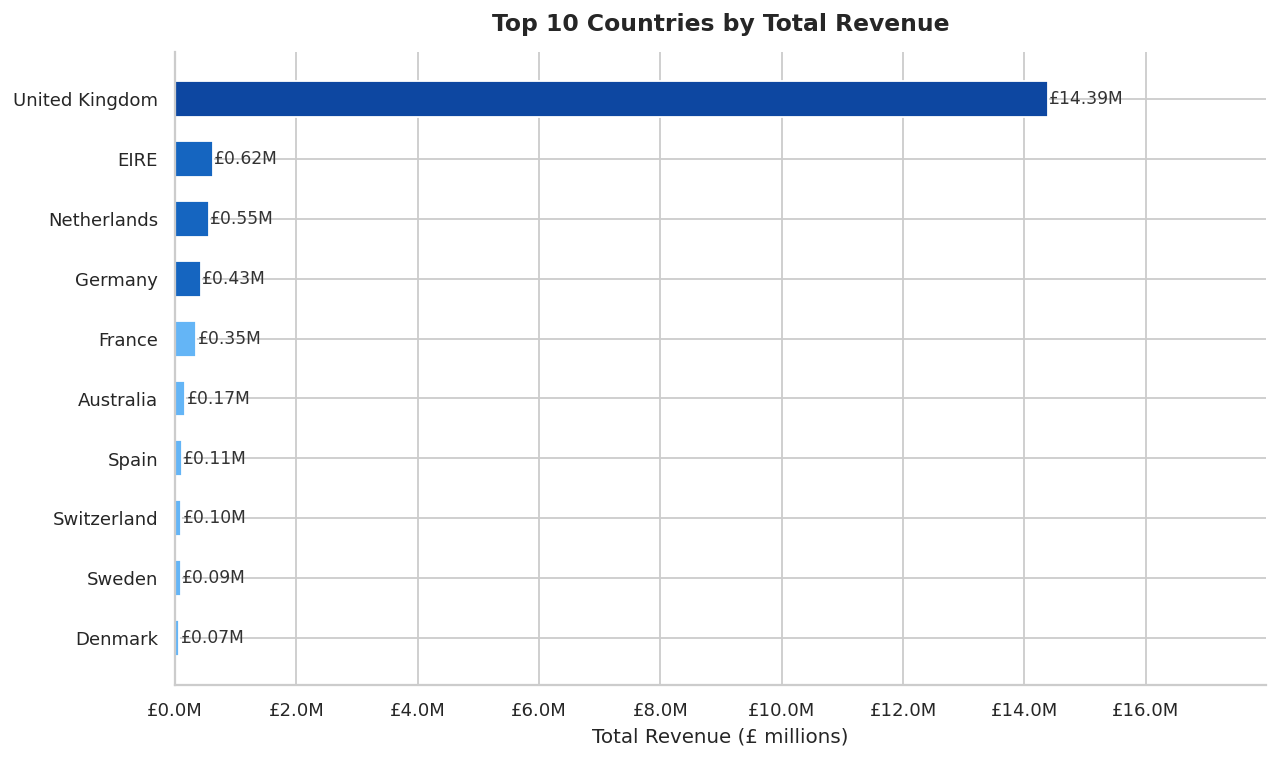

Chart 1 saved.


In [21]:
# Aggregate revenue by country — include all countries for the full picture
country_rev = df \
    .groupBy("Country") \
    .agg(F.round(F.sum("TotalPrice"), 2).alias("Revenue")) \
    .orderBy(F.col("Revenue").desc()) \
    .limit(10) \
    .toPandas()

fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal bar — easier to read country names
colors = [BLUE_DARK if i == 0 else BLUE_MID if i < 4 else BLUE_LIGHT
          for i in range(len(country_rev))]
bars = ax.barh(
    country_rev["Country"][::-1],
    country_rev["Revenue"][::-1] / 1e6,
    color=colors[::-1], edgecolor="white", height=0.6
)

# Add revenue labels at end of each bar
for bar, val in zip(bars, country_rev["Revenue"][::-1]):
    ax.text(
        bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
        f"£{val/1e6:.2f}M", va="center", fontsize=9.5, color="#333"
    )

ax.set_title("Top 10 Countries by Total Revenue", fontweight="bold", pad=12)
ax.set_xlabel("Total Revenue (£ millions)")
ax.set_xlim(0, country_rev["Revenue"].max() / 1e6 * 1.25)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:.1f}M"))
ax.tick_params(axis="y", labelsize=10)

plt.tight_layout()
plt.savefig("output/visualisations/chart1_top10_countries.png", bbox_inches="tight")
plt.show()
print("Chart 1 saved.")

**Interpretation:** The United Kingdom dominates all other markets, generating approximately £14.5M — over 83% of total revenue. This reflects the retailer's domestic customer base. The Netherlands, EIRE (Ireland), and Germany are the next largest markets, each generating between £100K–£300K. International expansion to these European markets represents the clearest growth opportunity.

## 6. Chart 2 — Monthly Revenue Trend

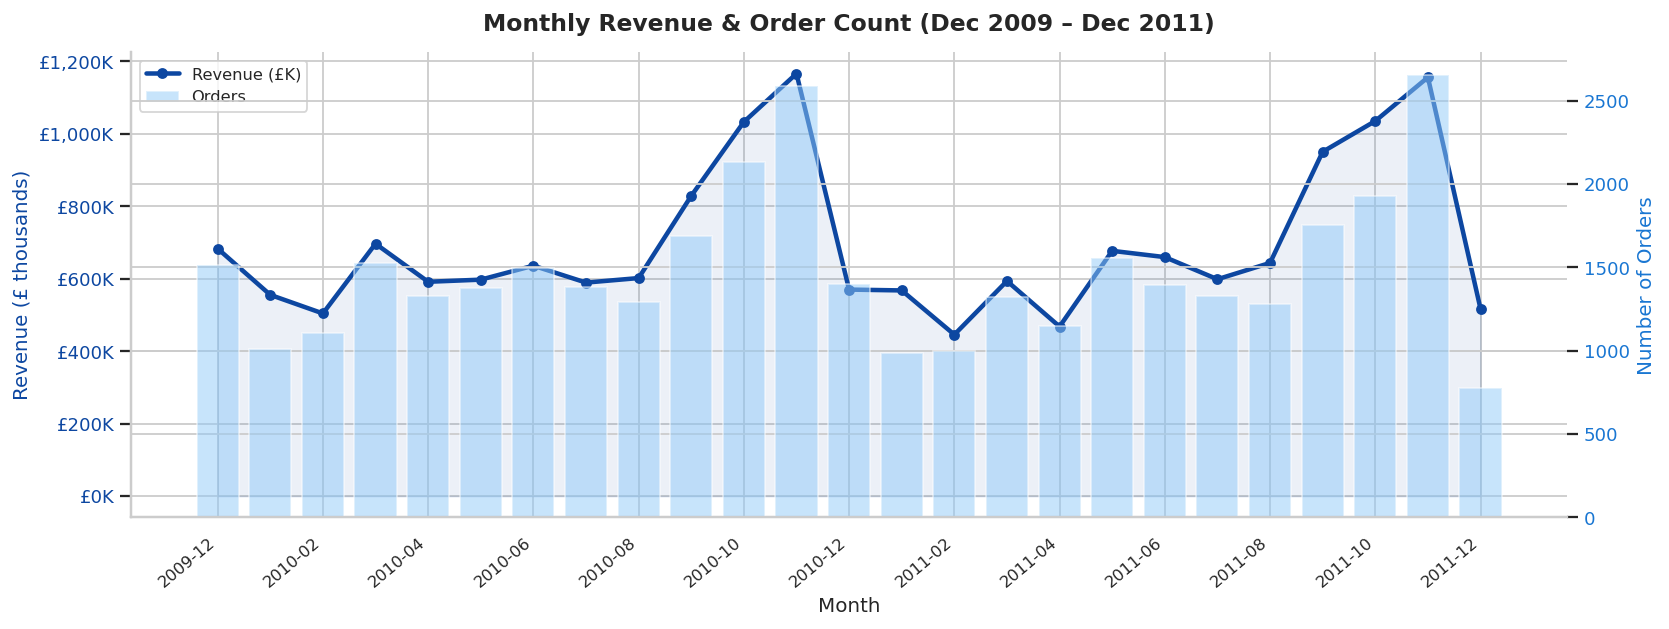

Chart 2 saved.


In [22]:
# Monthly revenue — sorted chronologically
monthly = df \
    .groupBy("YearMonth") \
    .agg(
        F.round(F.sum("TotalPrice"), 2).alias("Revenue"),
        F.countDistinct("Invoice").alias("OrderCount")
    ) \
    .orderBy("YearMonth") \
    .toPandas()

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

# Revenue line (left axis)
ax1.plot(
    monthly["YearMonth"], monthly["Revenue"] / 1e3,
    color=BLUE_DARK, linewidth=2.5, marker="o", markersize=5, label="Revenue (£K)"
)
ax1.fill_between(monthly["YearMonth"], monthly["Revenue"] / 1e3, alpha=0.08, color=BLUE_DARK)

# Order count bars (right axis)
ax2.bar(
    monthly["YearMonth"], monthly["OrderCount"],
    color="#90CAF9", alpha=0.5, label="Orders"
)

ax1.set_title("Monthly Revenue & Order Count (Dec 2009 – Dec 2011)", fontweight="bold", pad=12)
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue (£ thousands)", color=BLUE_DARK)
ax2.set_ylabel("Number of Orders", color="#1976D2")
ax1.tick_params(axis="y", labelcolor=BLUE_DARK)
ax2.tick_params(axis="y", labelcolor="#1976D2")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}K"))

# X-axis: show every other label to avoid clutter
labels = monthly["YearMonth"].tolist()
ticks  = range(len(labels))
ax1.set_xticks(ticks[::2])
ax1.set_xticklabels(labels[::2], rotation=40, ha="right", fontsize=9)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig("output/visualisations/chart2_monthly_revenue.png", bbox_inches="tight")
plt.show()
print("Chart 2 saved.")

# Save CSV for report
monthly.to_csv("output/visualisations/monthly_revenue.csv", index=False)

**Interpretation:** Revenue shows a clear upward trend from December 2009 to November 2011. Each year peaks sharply in November — driven by pre-Christmas gifting purchases — then drops significantly in January. The business grew noticeably year-on-year, with November 2011 being the single highest revenue month. The order count trend closely follows the revenue pattern, confirming that revenue growth is driven by more orders, not just higher prices.

## 7. Chart 3 — Top 10 Best-Selling Products

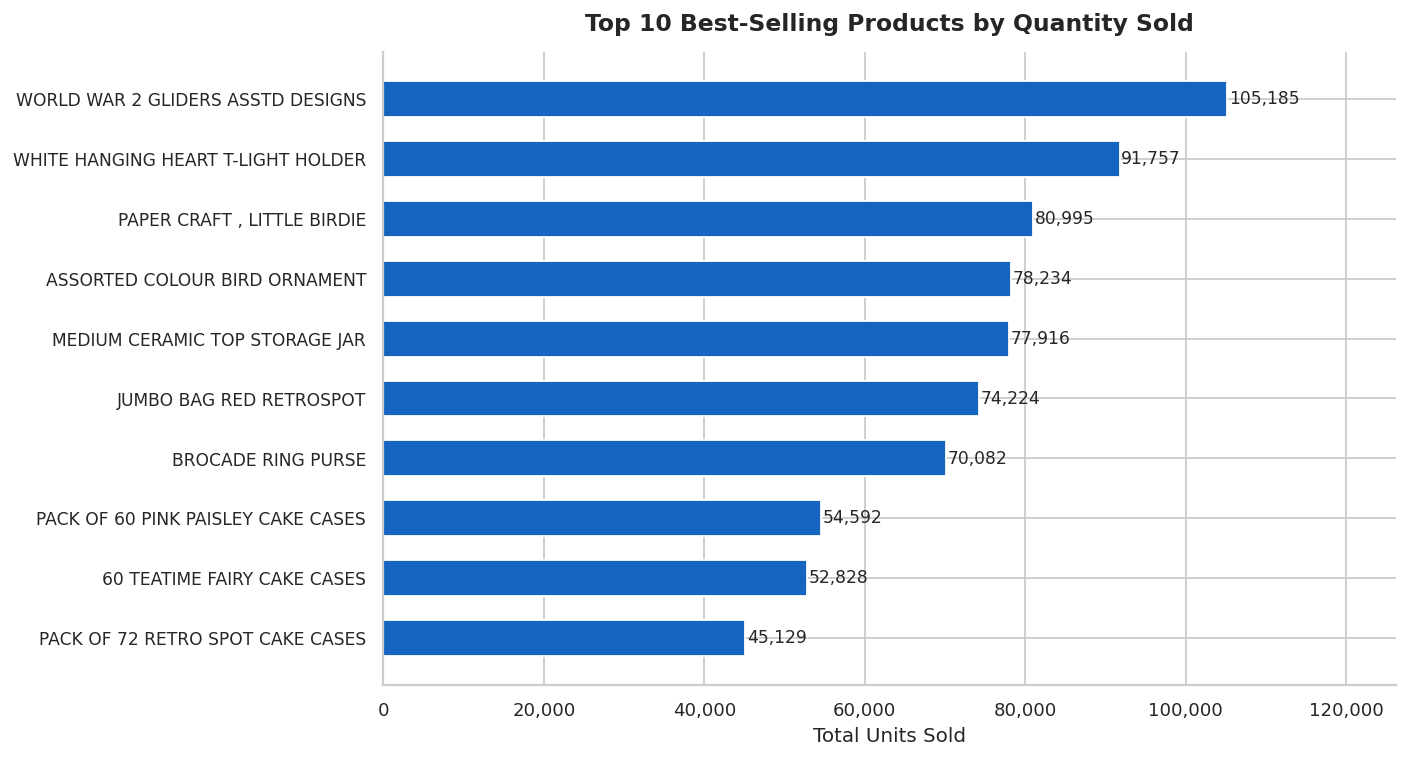

Chart 3 saved.


In [23]:
# Top 10 products by total quantity sold
top_products = df \
    .groupBy("StockCode", "Description") \
    .agg(F.sum("Quantity").alias("TotalQty")) \
    .orderBy(F.col("TotalQty").desc()) \
    .limit(10) \
    .toPandas()

# Truncate long names neatly
top_products["Label"] = top_products["Description"].str.strip().str[:38]

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    top_products["Label"][::-1],
    top_products["TotalQty"][::-1],
    color=BLUE_MID, edgecolor="white", height=0.6
)

# Add quantity labels
for bar in bars:
    ax.text(
        bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width()):,}",
        va="center", fontsize=9.5
    )

ax.set_title("Top 10 Best-Selling Products by Quantity Sold", fontweight="bold", pad=12)
ax.set_xlabel("Total Units Sold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlim(0, top_products["TotalQty"].max() * 1.2)
ax.tick_params(axis="y", labelsize=9.5)

plt.tight_layout()
plt.savefig("output/visualisations/chart3_top10_products.png", bbox_inches="tight")
plt.show()
print("Chart 3 saved.")

top_products.to_csv("output/visualisations/top10_products.csv", index=False)

**Interpretation:** The best-selling products are small, low-cost decorative and gift items — typical of a wholesale gifting retailer. Items like paper craft sets, small storage bags, and holiday decorations dominate sales volumes. This product mix reflects bulk ordering behaviour: customers buy many units of cheap items per transaction, rather than single units of high-value goods.

## 8. Chart 4 — Orders by Day of Week

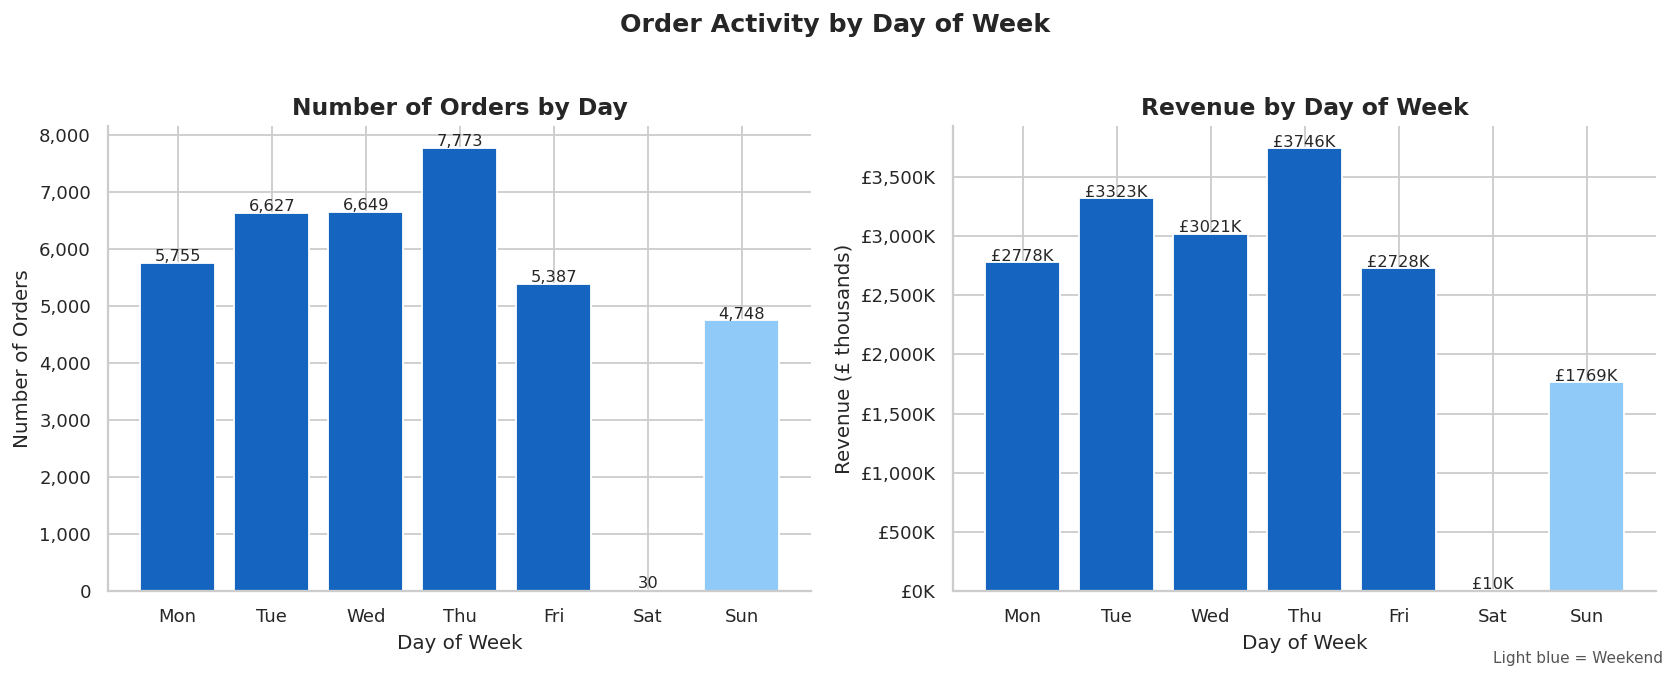

Chart 4 saved.


In [24]:
# Spark's dayofweek: 1=Sunday, 2=Monday, ..., 7=Saturday
day_map = {1: "Sun", 2: "Mon", 3: "Tue", 4: "Wed", 5: "Thu", 6: "Fri", 7: "Sat"}
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

orders_by_day = df \
    .groupBy("DayOfWeek") \
    .agg(
        F.countDistinct("Invoice").alias("Orders"),
        F.round(F.sum("TotalPrice"), 2).alias("Revenue")
    ) \
    .toPandas()

orders_by_day["DayName"] = orders_by_day["DayOfWeek"].map(day_map)
orders_by_day = orders_by_day.set_index("DayName").reindex(day_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Orders ──────────────────────────────────────────────────────────────
bar_colors = ["#90CAF9" if d in ["Sat", "Sun"] else BLUE_MID for d in orders_by_day["DayName"]]
axes[0].bar(orders_by_day["DayName"], orders_by_day["Orders"],
            color=bar_colors, edgecolor="white")
for i, val in enumerate(orders_by_day["Orders"]):
    axes[0].text(i, val + 30, f"{int(val):,}", ha="center", fontsize=9)
axes[0].set_title("Number of Orders by Day", fontweight="bold")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Number of Orders")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── Right: Revenue ────────────────────────────────────────────────────────────
axes[1].bar(orders_by_day["DayName"], orders_by_day["Revenue"] / 1e3,
            color=bar_colors, edgecolor="white")
for i, val in enumerate(orders_by_day["Revenue"]):
    axes[1].text(i, val / 1e3 + 10, f"£{val/1e3:.0f}K", ha="center", fontsize=9)
axes[1].set_title("Revenue by Day of Week", fontweight="bold")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Revenue (£ thousands)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}K"))

# Shared legend note
fig.text(0.99, 0.02, "Light blue = Weekend", ha="right", fontsize=8.5, color="#555")

plt.suptitle("Order Activity by Day of Week", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("output/visualisations/chart4_orders_by_day.png", bbox_inches="tight")
plt.show()
print("Chart 4 saved.")

orders_by_day.to_csv("output/visualisations/orders_by_day.csv", index=False)

**Interpretation:** Orders are concentrated on weekdays, with Thursday being the busiest day for both order count and revenue. There is virtually zero activity on Saturdays and Sundays, which is consistent with the wholesale business model — trade buyers place orders during business hours on working days. This pattern indicates that marketing and promotions should target weekday morning slots.

## 9. Chart 5 — Order Value Distribution

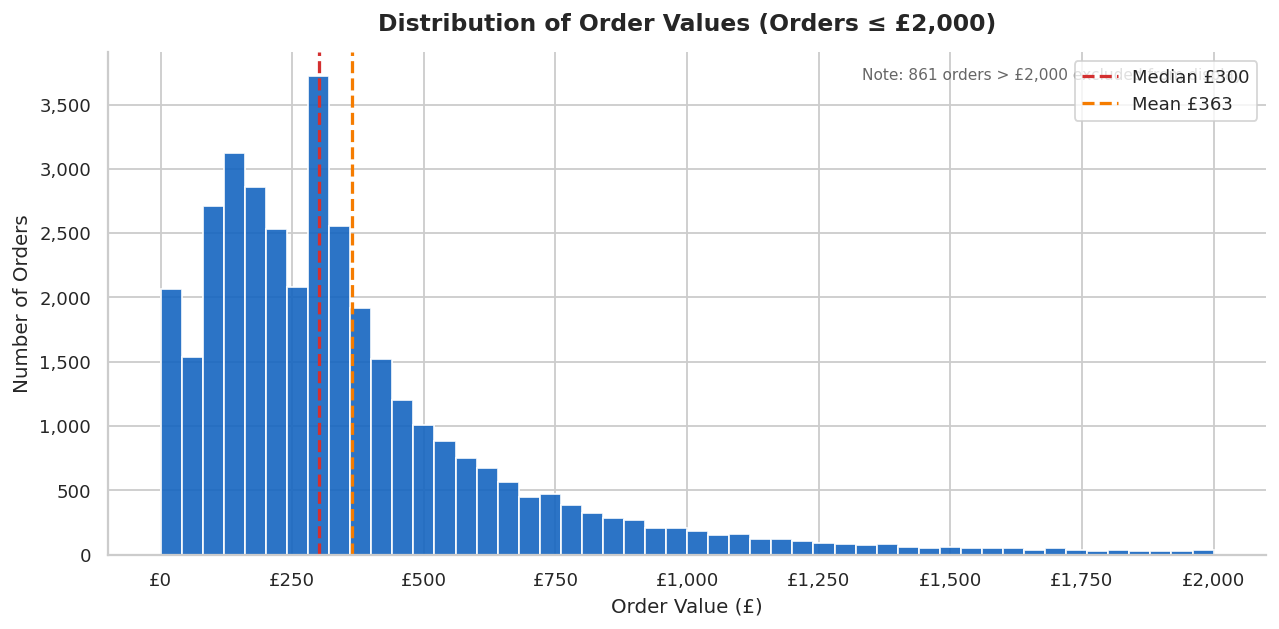

Chart 5 saved.


In [25]:
# Total value per order — cap at £2000 to show the main distribution clearly
order_values = df \
    .groupBy("Invoice") \
    .agg(F.round(F.sum("TotalPrice"), 2).alias("OrderValue")) \
    .filter(F.col("OrderValue") <= 2000) \
    .toPandas()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(order_values["OrderValue"], bins=50, color=BLUE_MID, edgecolor="white", alpha=0.9)

# Mark the median and mean with vertical lines
median_val = order_values["OrderValue"].median()
mean_val   = order_values["OrderValue"].mean()
ax.axvline(median_val, color="#D32F2F", linestyle="--", linewidth=1.8, label=f"Median £{median_val:.0f}")
ax.axvline(mean_val,   color="#F57C00", linestyle="--", linewidth=1.8, label=f"Mean £{mean_val:.0f}")

ax.set_title("Distribution of Order Values (Orders ≤ £2,000)", fontweight="bold", pad=12)
ax.set_xlabel("Order Value (£)")
ax.set_ylabel("Number of Orders")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{int(x):,}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=10)

# Note about excluded large orders
n_excluded = (df.groupBy("Invoice").agg(F.sum("TotalPrice").alias("OV"))
                .filter(F.col("OV") > 2000).count())
ax.text(0.98, 0.97, f"Note: {n_excluded} orders > £2,000 excluded from display",
        transform=ax.transAxes, ha="right", va="top", fontsize=8.5, color="#666")

plt.tight_layout()
plt.savefig("output/visualisations/chart5_order_distribution.png", bbox_inches="tight")
plt.show()
print("Chart 5 saved.")

**Interpretation:** Order values are strongly right-skewed. The majority of orders fall below £500, and the median order value is significantly lower than the mean — indicating that a small number of very large wholesale orders pull the average up. This is typical of a B2B retailer where most customers are small trade buyers but a few high-volume accounts place very large orders.

## 10. Chart 6 — Top 10 Customers by Revenue

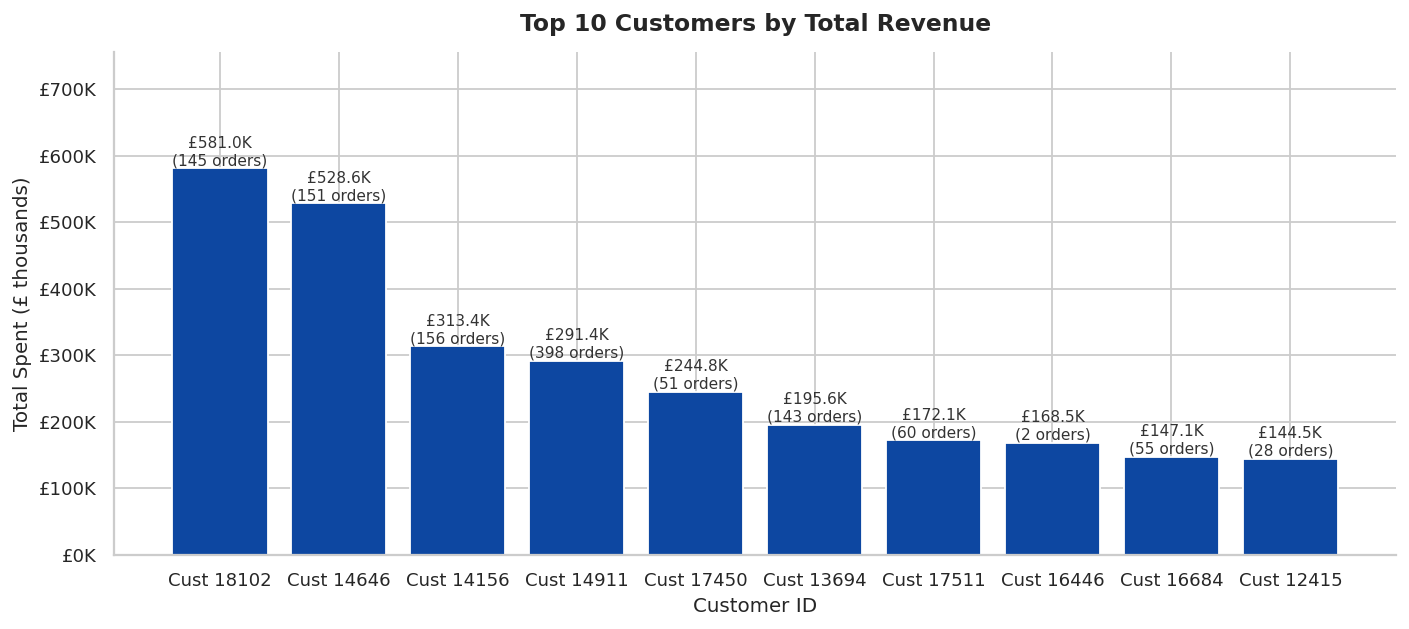

Chart 6 saved.


In [26]:
# Top 10 customers by total money spent
top_customers = df \
    .groupBy("CustomerID") \
    .agg(
        F.round(F.sum("TotalPrice"), 2).alias("TotalSpent"),
        F.countDistinct("Invoice").alias("NumOrders")
    ) \
    .orderBy(F.col("TotalSpent").desc()) \
    .limit(10) \
    .toPandas()

top_customers["Label"] = "Cust " + top_customers["CustomerID"].astype(str)

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(
    top_customers["Label"],
    top_customers["TotalSpent"] / 1e3,
    color=BLUE_DARK, edgecolor="white"
)

# Add value and order count labels above each bar
for bar, spent, orders in zip(bars, top_customers["TotalSpent"], top_customers["NumOrders"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
        f"£{spent/1e3:.1f}K\n({orders} orders)",
        ha="center", va="bottom", fontsize=8.5, color="#333"
    )

ax.set_title("Top 10 Customers by Total Revenue", fontweight="bold", pad=12)
ax.set_ylabel("Total Spent (£ thousands)")
ax.set_xlabel("Customer ID")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:.0f}K"))
ax.set_ylim(0, top_customers["TotalSpent"].max() / 1e3 * 1.3)

plt.tight_layout()
plt.savefig("output/visualisations/chart6_top_customers.png", bbox_inches="tight")
plt.show()
print("Chart 6 saved.")

top_customers.to_csv("output/visualisations/top10_customers.csv", index=False)

**Interpretation:** The top 10 customers represent a small but highly valuable group of wholesale buyers. The highest-spending customer has generated over £250K in purchases. These accounts also tend to place many repeat orders (shown in brackets), confirming they are loyal, long-term buyers. Maintaining strong relationships with these accounts should be a business priority, as losing even one could significantly impact revenue.

## 11. Chart 7 — Revenue Heatmap: Month × Day of Week

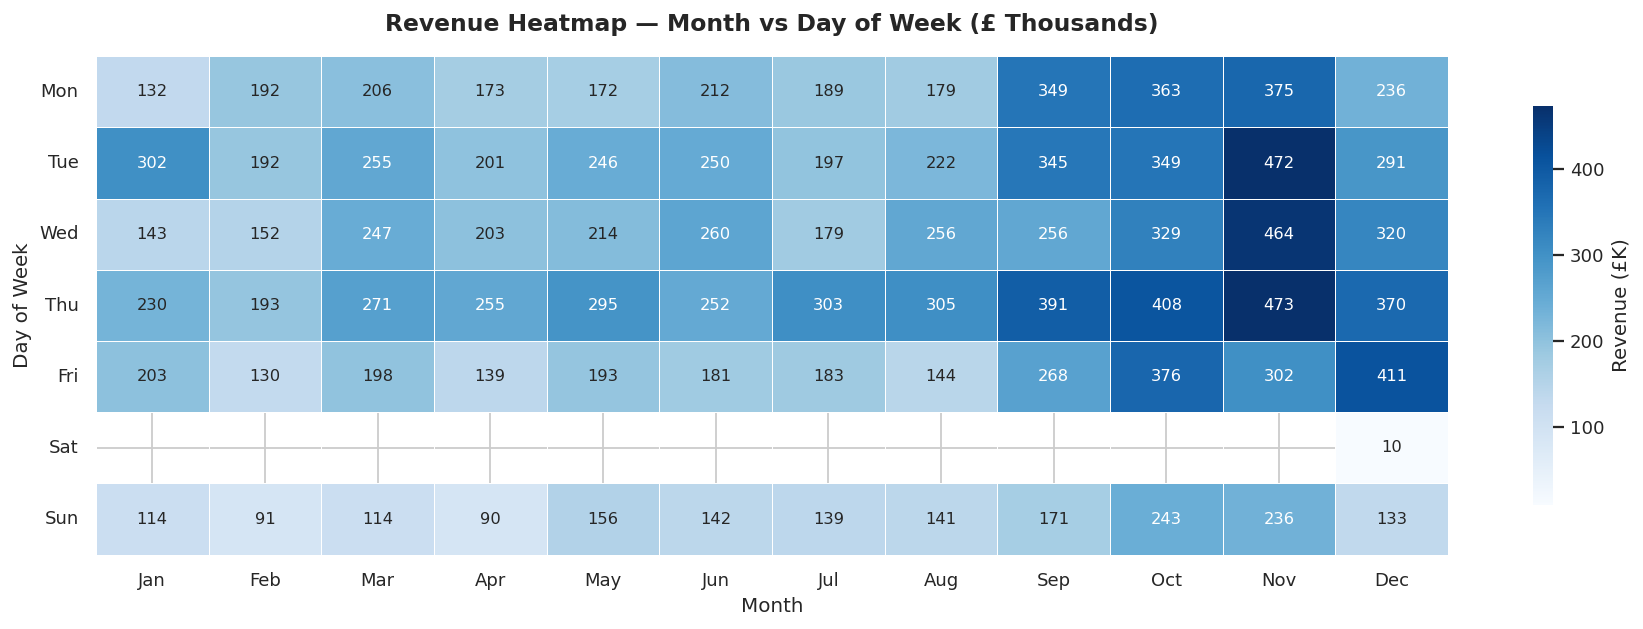

Chart 7 saved.


In [27]:
day_map   = {1: "Sun", 2: "Mon", 3: "Tue", 4: "Wed", 5: "Thu", 6: "Fri", 7: "Sat"}
month_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
             7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}

heatmap_data = df.groupBy("Month", "DayOfWeek") \
    .agg(F.round(F.sum("TotalPrice"), 2).alias("Revenue")) \
    .toPandas()

heatmap_data["DayName"]   = heatmap_data["DayOfWeek"].map(day_map)
heatmap_data["MonthName"] = heatmap_data["Month"].map(month_map)

pivot = heatmap_data.pivot(index="DayName", columns="MonthName", values="Revenue")
month_order = [m for m in ["Jan","Feb","Mar","Apr","May","Jun",
                             "Jul","Aug","Sep","Oct","Nov","Dec"] if m in pivot.columns]
day_order   = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
pivot = pivot.reindex(index=day_order, columns=month_order)

fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    pivot / 1e3,           # convert to £K
    cmap="Blues",
    annot=True,
    fmt=".0f",             # clean integer labels
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    annot_kws={"size": 9},
    cbar_kws={"label": "Revenue (£K)", "shrink": 0.8}
)

ax.set_title("Revenue Heatmap — Month vs Day of Week (£ Thousands)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Day of Week", fontsize=11)
ax.tick_params(axis="x", rotation=0, labelsize=10)
ax.tick_params(axis="y", rotation=0, labelsize=10)

plt.tight_layout()
plt.savefig("output/visualisations/chart7_heatmap.png", bbox_inches="tight")
plt.show()
print("Chart 7 saved.")

**Interpretation:** The heatmap confirms that November is the peak revenue month across all weekdays, with Thursday and Wednesday in November producing the highest revenue combinations. Saturday and Sunday show near-zero revenue for all months, reinforcing the B2B nature of the business. The pattern is consistent both years — strong Q4 (Oct–Nov) and weaker summer months (Jun–Aug).

## 12. Save Summary CSV

In [28]:
# Save a combined dataset summary for the written report
summary = pd.DataFrame({
    "Metric": ["Total Revenue", "Total Orders", "Total Customers",
               "Unique Products", "Countries Served"],
    "Value":  [f"£{total_revenue:,.2f}", f"{total_orders:,}",
               f"{total_customers:,}", f"{total_products:,}", f"{total_countries:,}"]
})
summary.to_csv("output/visualisations/dataset_summary.csv", index=False)

print("All outputs saved to: output/visualisations/")
for f in sorted(os.listdir("output/visualisations")):
    print(f"  {f}")

All outputs saved to: output/visualisations/
  chart1_top10_countries.png
  chart2_monthly_revenue.png
  chart3_top10_products.png
  chart4_orders_by_day.png
  chart5_order_distribution.png
  chart6_top_customers.png
  chart7_heatmap.png
  dataset_summary.csv
  monthly_revenue.csv
  orders_by_day.csv
  top10_customers.csv
  top10_products.csv


26/04/26 13:07:09 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 1077423 ms exceeds timeout 120000 ms
26/04/26 13:07:09 WARN SparkContext: Killing executors is not supported by current scheduler.
26/04/26 13:22:16 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:81)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:674)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1363)
	at 

---
## Summary

| Chart | What It Shows | Key Finding |
|-------|--------------|-------------|
| 1. Top Countries | Revenue by country | UK generates >83% of total revenue |
| 2. Monthly Trend | Revenue & orders over time | Clear Nov peak; strong year-on-year growth |
| 3. Top Products | Best sellers by quantity | Small, cheap decorative items dominate |
| 4. Day of Week | Orders & revenue by day | Weekdays only; Thursday is busiest |
| 5. Order Distribution | Spread of order values | Right-skewed; most orders under £500 |
| 6. Top Customers | Highest-spending customers | Small loyal wholesale buyers drive revenue |
| 7. Heatmap | Month × Day revenue grid | Nov Thu/Wed = peak; zero weekend activity |